# Orchestador Principal - Modelos de Recomendación Anime

Este notebook se encarga de unificar el proceso de carga de datos, instanciación y comparación de todas las arquitecturas de recomendación (KNN, PMF, BMF, NCF).

## 0. Imports

In [4]:
import polars as pl
import pandas as pd
import numpy as np
import pickle
import scipy.sparse as sp
import matplotlib.pyplot as plt   
import seaborn as sns
import torch

# Importamos las diferentes técnicas de recomendación que hemos implementado
from algoritmos.knn import run_knn
from algoritmos.pmf import run_pmf
from results.optimize_gmf import check_or_run_optuna_gmf
from algoritmos.gmf import run_gmf
from results.optimize_mlp import check_or_run_optuna_mlp
from algoritmos.mlp import run_mlp

import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual para las gráficas
sns.set_theme(style="whitegrid")

c:\Users\serg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de Datos y Mapeos

In [6]:
# Cargar DataFrames en Pandas
df_train_pl = pl.read_parquet("data/train.parquet")
df_test_pl = pl.read_parquet("data/test.parquet")

df_train = df_train_pl.to_pandas()
df_test = df_test_pl.to_pandas()

# Cargar los mapeos guardados por preprocess.py
with open("data/mapeos.pkl", "rb") as f:
    mapeos = pickle.load(f)

user2idx = mapeos['user2idx']
anime2idx = mapeos['anime2idx']

NUM_USERS = len(user2idx)
NUM_ITEMS = len(anime2idx)

print(f"Usuarios únicos: {NUM_USERS}")
print(f"Items únicos: {NUM_ITEMS}")
print(f"Interacciones Train: {len(df_train):,}")
print(f"Interacciones Test: {len(df_test):,}")

Usuarios únicos: 47143
Items únicos: 6532
Interacciones Train: 4,915,940
Interacciones Test: 1,228,986


## 2. Preparación para PMF (Matrices Dispersas)

In [7]:
# PMF necesita las matrices dispersas CSR generadas a partir de ratings (1 a 10)
R_train_sparse = sp.csr_matrix(
    (df_train['rating'].values, (df_train['user_id'].values, df_train['anime_id'].values)), 
    shape=(NUM_USERS, NUM_ITEMS)
)

R_test_sparse = sp.csr_matrix(
    (df_test['rating'].values, (df_test['user_id'].values, df_test['anime_id'].values)), 
    shape=(NUM_USERS, NUM_ITEMS)
)

MU = df_train['rating'].mean()
print(f"Media global de entrenamiento (MU): {MU:.4f}")

Media global de entrenamiento (MU): 7.7929


## 3. Modelo 1 - KNN (K-Nearest Neighbors)

### Guía Teórica y Técnica: Modelo KNN para el Sistema de Recomendación de Anime

Este documento proporciona una explicación detallada del modelo **K-Nearest Neighbors (KNN)** implementado en el módulo `knn.py`, sirviendo como preámbulo teórico y técnico antes de ejecutar el análisis y optimización en `main.ipynb`. 

---

#### 1. Introducción a KNN en Sistemas de Recomendación

El algoritmo **K-Nearest Neighbors (K-Vecinos Más Cercanos)** es un método no paramétrico clásico dentro de los sistemas de recomendación basados en **Filtrado Colaborativo**. Su premisa fundamental es que las preferencias pasadas de los usuarios estables reflejan comportamientos futuros similares.

En tu arquitectura coexisten **dos variantes complementarias** de este enfoque:

1. **User-Based Collaborative Filtering (Basado en Usuarios):** Es el corazón de la clase personalizada `KNNRecommender`. Para predecir el interés de un usuario activo $u$ por un anime $i$, el algoritmo identifica a los $K$ usuarios más similares a $u$ que ya han calificado al anime $i$, combinando sus desviaciones y preferencias.
2. **Item-Based Collaborative Filtering (Basado en Ítems):** Es la variante ejecutada a través de `scikit-learn` en la función `generar_resultados_knn_frontend`. Calcula la similitud geométrica entre vectores de animes en el espacio de calificaciones de los usuarios. Es más estable ante catálogos con interacciones masivas y es ideal para construir el grafo de relaciones (*Source-Target*) del frontend.

---

#### 2. Preparación y Estructura Eficiente de Datos

Un desafío crítico en los modelos KNN es la **dispersión (sparsity)** de la matriz de utilidad Usuario-Ítem. En sistemas reales, un usuario común califica un porcentaje ínfimo del catálogo completo de animes. Si se representara esta información como una matriz densa tradicional, los millones de celdas vacías (`NaN` o `0`) colapsarían la memoria RAM.

Tu código aborda este desafío de dos formas óptimas:
* **Estructuras de Diccionarios Indexados (`ratings_train`):** En `KNNRecommender`, se construyen mapas hash de Python (`dict` de `dict`) que indexan únicamente las interacciones existentes. Esto reduce el costo computacional de buscar elementos de $\mathcal{O}(N)$ a $\mathcal{O}(1)$ en promedio.
* **Matrices CSR (Compressed Sparse Row):** En la integración con `sklearn`, se utiliza `scipy.sparse.csr_matrix`. Esta estructura almacena en vectores contiguos los valores indexados por filas, eliminando los ceros del cómputo y permitiendo operaciones vectoriales ultrarrápidas mediante álgebra lineal en C/C++.

---

#### 3. Métricas de Similitud Implementadas

El cálculo de la "cercanía" geométrica define la precisión de los vecinos elegidos. Tu archivo `knn.py` implementa tres métricas fundamentales con propiedades matemáticas particulares:

##### A. Similitud de Correlación (Pearson)
Mide la relación lineal entre las calificaciones co-emitidas por dos usuarios $u$ y $v$. Su gran ventaja matemática es que **corrige el sesgo de calificación individual** (el centrado respecto a la media de cada usuario).

$$
sim(u, v) = \frac {
    \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)
   }{
   \sqrt{ \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)^2 \sum_{i \in I_{u,v}} (r_{v,i} - \bar{r}_v)^2 }
   }
$$


##### B. Similitud JMSD (Jaccard + Mean Squared Difference)
Es una métrica híbrida de última generación para sistemas de recomendación que mitiga las limitaciones individuales de Jaccard y MSD:

1. **Coeficiente de Jaccard:** Evalúa la proporción de solapamiento del consumo implícito, midiendo cuántos animes comparten en comparación con la unión de sus catálogos visitados.
2. **Mean Squared Difference (MSD):** Evalúa la distancia euclidiana promedio al cuadrado de las calificaciones sobre los ítems comunes.

$$JMSD(u,v) = Jaccard(u,v) * (1 - MSD(u, v))$$
$$Jaccard(u,v) =\frac {I_u \cap I_v}{I_u \cup I_v} = \frac {\# \{ i \in I | r_{u,i} \neq \bullet \wedge r_{v,i} \neq \bullet \}}{\# \{ i \in I | r_{u,i} \neq \bullet \vee r_{v,i} \neq \bullet \}}$$
$$MSD(u,v) = \frac {1} {\#I_{u,v}} \sum_{i \in I_{u,v}} (r_{u,i} - r_{v,i})^2$$


*Nota técnica:* JMSD destaca porque equilibra la similitud cuantitativa (coincidencia exacta en la nota) con la similitud cualitativa (coincidencia en el hábito de ver el mismo anime).

---

#### 4. El Algoritmo de Predicción (Fórmula de Resnick)

Una vez seleccionados los $K$ vecinos más cercanos al usuario $u$ que han consumido el anime $i$, no basta con promediar sus notas de forma simple. Los usuarios tienen diferentes escalas internas (un usuario exigente puede considerar un $7/10$ una obra maestra, mientras que otro optimista califica todo con $9/10$).

Nuestra función `prediction_knn` implementa la **Fórmula de Resnick con ajuste por la media del usuario**, la cual normaliza el comportamiento y calcula una suma ponderada por la similitud del vecino:

$$\hat{r}_{u,i} = \bar{r}_{u} + \frac{\sum_{v \in N} sim(u,v) \cdot (r_{v,i} - \bar{r}_v)}{\sum_{v \in N} |sim(u,v)|} $$

Donde:
* $\hat{r}_{u,i}$ es la calificación predicha para el usuario $u$ sobre el anime $i$.
* $ \bar{r}_{u}$ es la media global del usuario activo (la línea base sobre la cual se proyecta la recomendación).
* $r_{v,i} -  \bar{r}_{u}$ es la desviación del vecino $v$; indica si al vecino ese anime le gustó más o menos de lo que le suele gustar el anime promedio.
* El denominador normaliza la influencia asegurando que el resultado permanezca estrictamente en la escala permitida (restringida mediante `np.clip` entre `R_MIN=1` y `R_MAX=10`).

---

#### 5. Protocolo de Evaluación y Métricas de Rendimiento

Para validar empíricamente el comportamiento del modelo según la variación de $K$, la función `evaluate` implementa tres indicadores clave:

1. **RMSE (Root Mean Squared Error):** Penaliza severamente los errores grandes debido a la elevación al cuadrado. Es el estándar de la industria.

2. **MAE (Mean Absolute Error):** Mide la magnitud promedio del error en valores absolutos, ofreciendo una interpretación lineal directa del desvío (ej. "el modelo se equivoca en promedio $\pm 1.1$ puntos").
 
3. **Cobertura (Prediction Coverage):** Determina el porcentaje de interacciones del conjunto de prueba para las cuales el modelo fue capaz de encontrar vecinos válidos y generar una predicción numérica real. Si un anime es extremadamente raro, o un usuario no comparte historial con nadie, la predicción retorna `None` y reduce la cobertura.



**OUTPUT ESPERADO**

1. **La Gráfica del Codo**

2. **Evaluación Transparente**

3. **Muestra Inteligente**: El DataFrame de pandas final creará una nueva columna llamada Diferencia_Absoluta pintada en un gradiente rojo. Esto  permitirá ver de un vistazo en qué usuarios el KNN acertó (colores claros o blancos) y en cuáles falló por mucha diferencia de nota (colores rojos intensos).

In [8]:
# 1. Ejecutamos el modelo obteniendo 4 variables de retorno
# Nota: Puedes cambiar force_recompute=True si cambias los k_values y quieres re-entrenar
df_results_knn, knn_model, best_k, best_df_preds = run_knn(
    df_train, 
    df_test.sample(1500, random_state=42), 
    k_values=[5, 10, 20, 30, 50, 75, 100],
    force_recompute=False 
)

# 2. Gráfica de Elección del K Óptimo
plt.figure(figsize=(10, 5))
plt.plot(df_results_knn['K'], df_results_knn['RMSE'], marker='o', color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(df_results_knn['K'], df_results_knn['MAE'], marker='s', color='#ff7f0e', label='MAE (Error Absoluto)')

# Extraer el mejor valor para resaltarlo visualmente
best_rmse = df_results_knn['RMSE'].min()
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'K Óptimo ({best_k})')
plt.scatter(best_k, best_rmse, color='red', s=100, zorder=5) # Punto rojo en el mínimo

plt.title('Evolución del Error según el Número de Vecinos (K)', fontsize=14)
plt.xlabel('Número de Vecinos (K)', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(df_results_knn['K']) # Mostrar todos los valores de K en el eje X
plt.legend()
plt.show()

# 3. Impresión de Métricas de Evaluación
best_mae = df_results_knn.loc[df_results_knn['K'] == best_k, 'MAE'].values[0]
best_cob = df_results_knn.loc[df_results_knn['K'] == best_k, 'Cobertura'].values[0]

print("="*40)
print(f"🏆 MÉTRICAS DEL MEJOR MODELO KNN (K={best_k}) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {best_rmse:.4f}")
print(f"MAE (Mean Absolute Error)    : {best_mae:.4f}")
print(f"Cobertura de Predicción      : {best_cob:.2f}%")
print("="*40)

# 4. Muestra de predicciones en X usuarios
print("\n Muestra de Predicciones Realizadas vs Rating Real:")
# Tomamos 10 usuarios/items aleatorios de la evaluación para comparar
muestra = best_df_preds.sample(10, random_state=42)

# Coloreamos las columnas para ver la diferencia entre lo predicho y lo real
muestra['Diferencia_Absoluta'] = abs(muestra['rating_real'] - muestra['rating_predicho'])
display(muestra.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))



>> Inicializando modelo KNN...
Construyendo matriz interna KNN...
Cargando resultados de K guardados previamente desde results/resultados_k_optimo.csv...
>> Generando predicciones de muestra para el mejor K (k = 10) a partir del test...


KeyboardInterrupt: 

## 4. Modelo 2 - PMF (Probabilistic Matrix Factorization)

El segundo modelo implementado es **PMF (Probabilistic Matrix Factorization)**, una técnica de filtrado colaborativo basada en factorización matricial. A diferencia de KNN, que busca usuarios parecidos a partir de similitudes explícitas, PMF intenta aprender una representación interna de usuarios y animes mediante **factores latentes**. Estos factores no se definen manualmente, sino que el modelo los aprende durante el entrenamiento a partir de las valoraciones conocidas.

La idea principal es que cada usuario y cada anime se representan mediante un vector de características latentes. Si el vector de un usuario y el vector de un anime son compatibles, el producto entre ambos será alto y la valoración predicha también tenderá a ser alta. En cambio, si no son compatibles, la predicción será menor.

En esta implementación se utiliza una versión de PMF con sesgos (*bias*), ya que no todos los usuarios puntúan de la misma forma ni todos los animes tienen la misma tendencia general de valoración. Algunos usuarios suelen puntuar más alto o más bajo que la media, y algunos animes suelen recibir mejores o peores valoraciones de forma general.

La predicción se calcula mediante la siguiente fórmula:

$$
\hat{r}_{u,i} = \mu + b_u + b_i + P_u \cdot Q_i
$$

Donde:

- $\hat{r}_{u,i}$ es la valoración predicha del usuario $u$ para el anime $i$.
- $\mu$ es la media global de las valoraciones del conjunto de entrenamiento.
- $b_u$ es el sesgo del usuario $u$.
- $b_i$ es el sesgo del anime $i$.
- $P_u$ es el vector de factores latentes del usuario.
- $Q_i$ es el vector de factores latentes del anime.
- $P_u \cdot Q_i$ es el producto escalar entre ambos vectores.

El entrenamiento se realiza mediante **descenso por gradiente estocástico (SGD)**. Para cada valoración conocida, el modelo calcula una predicción, obtiene el error respecto a la valoración real y actualiza los factores latentes y los sesgos para reducir ese error. Además, se aplica regularización para evitar que los parámetros crezcan demasiado y el modelo se ajuste en exceso al conjunto de entrenamiento.

Durante el entrenamiento se calcula el **RMSE** tanto en train como en test para observar la evolución del modelo. También se utiliza **early stopping**, que detiene el entrenamiento si el RMSE de test deja de mejorar durante varias épocas seguidas. Esto ayuda a evitar entrenamientos innecesarios y reduce el riesgo de sobreajuste.

En la implementación, la función `run_pmf` se encarga de crear el modelo, entrenarlo, evaluarlo y devolver los resultados principales: el historial de RMSE por época, el modelo PMF entrenado, el mejor RMSE obtenido en test y las predicciones realizadas sobre el conjunto de test.

In [ ]:
import sys
import os
sys.path.append("algoritmos")


from algoritmos.pmf import run_pmf

# Si es False y ya existen los CSV, no vuelve a entrenar
force_recompute_pmf = False

resultados_file = "results/resultados_pmf.csv"
predicciones_file = "results/predicciones_pmf.csv"
tuning_file = "results/tuning_pmf.csv"

# Si ya existen los tres archivos y no queremos recalcular, cargamos rápido
if (
    os.path.exists(resultados_file)
    and os.path.exists(predicciones_file)
    and os.path.exists(tuning_file)
    and not force_recompute_pmf
):
    print("Cargando resultados PMF guardados...")

    df_resultados_pmf = pd.read_csv(resultados_file)
    df_predicciones_pmf = pd.read_csv(predicciones_file)
    df_tuning_pmf = pd.read_csv(tuning_file)

else:
    param_grid_pmf = [
        {"n_factors": 20, "lr": 0.005, "reg": 0.05, "epochs": 15, "patience": 4},
        {"n_factors": 30, "lr": 0.005, "reg": 0.05, "epochs": 20, "patience": 4},
        {"n_factors": 50, "lr": 0.005, "reg": 0.05, "epochs": 30, "patience": 5},
        {"n_factors": 50, "lr": 0.005, "reg": 0.10, "epochs": 30, "patience": 5},
    ]

    lista_resultados = []
    lista_predicciones = []
    lista_tuning = []

    for params in param_grid_pmf:
        experimento = (
            f"pmf_f{params['n_factors']}"
            f"_lr{str(params['lr']).replace('.', '')}"
            f"_reg{str(params['reg']).replace('.', '')}"
        )

        print("\n" + "="*70)
        print(f"Probando configuración: {experimento}")
        print(params)
        print("="*70)

        df_results_tmp, pmf_tmp, best_rmse_tmp, df_preds_tmp = run_pmf(
            R_train_sparse,
            R_test_sparse,
            mu=MU,
            n_users=NUM_USERS,
            n_items=NUM_ITEMS,
            n_factors=params["n_factors"],
            lr=params["lr"],
            reg=params["reg"],
            epochs=params["epochs"],
            patience=params["patience"],
            force_recompute=True,
        )

        # Añadimos información del experimento a la evolución del RMSE
        df_results_tmp["experimento"] = experimento
        df_results_tmp["n_factors"] = params["n_factors"]
        df_results_tmp["lr"] = params["lr"]
        df_results_tmp["reg"] = params["reg"]
        df_results_tmp["patience"] = params["patience"]

        # Añadimos información del experimento a las predicciones
        df_preds_tmp["experimento"] = experimento
        df_preds_tmp["n_factors"] = params["n_factors"]
        df_preds_tmp["lr"] = params["lr"]
        df_preds_tmp["reg"] = params["reg"]

        lista_resultados.append(df_results_tmp)
        lista_predicciones.append(df_preds_tmp)

        # Resumen para comparar hiperparámetros
        lista_tuning.append({
            "experimento": experimento,
            "n_factors": params["n_factors"],
            "lr": params["lr"],
            "reg": params["reg"],
            "epochs": params["epochs"],
            "patience": params["patience"],
            "best_RMSE": best_rmse_tmp,
            "train_RMSE_final": df_results_tmp["train_RMSE"].iloc[-1],
            "test_RMSE_final": df_results_tmp["test_RMSE"].iloc[-1]
        })

    # Unimos todos los experimentos
    df_resultados_pmf = pd.concat(lista_resultados, ignore_index=True)
    df_predicciones_pmf = pd.concat(lista_predicciones, ignore_index=True)
    df_tuning_pmf = pd.DataFrame(lista_tuning).sort_values("best_RMSE")

    # Guardamos solo tres archivos
    os.makedirs("results", exist_ok=True)

    df_resultados_pmf.to_csv(resultados_file, index=False)
    df_predicciones_pmf.to_csv(predicciones_file, index=False)
    df_tuning_pmf.to_csv(tuning_file, index=False)

df_tuning_pmf


Probando configuración: pmf_f20_lr0005_reg005
{'n_factors': 20, 'lr': 0.005, 'reg': 0.05, 'epochs': 15, 'patience': 4}
>> Inicializando modelo PMF...
>> Entrenando modelo PMF...
  Época  1/15 | Train RMSE: 1.2627 | Test RMSE: 1.2700
  Época  2/15 | Train RMSE: 1.2229 | Test RMSE: 1.2330
  Época  3/15 | Train RMSE: 1.2063 | Test RMSE: 1.2182
  Época  4/15 | Train RMSE: 1.1959 | Test RMSE: 1.2096
  Época  5/15 | Train RMSE: 1.1853 | Test RMSE: 1.2010
  Época  6/15 | Train RMSE: 1.1721 | Test RMSE: 1.1903
  Época  7/15 | Train RMSE: 1.1594 | Test RMSE: 1.1805
  Época  8/15 | Train RMSE: 1.1488 | Test RMSE: 1.1730
  Época  9/15 | Train RMSE: 1.1393 | Test RMSE: 1.1667
  Época 10/15 | Train RMSE: 1.1300 | Test RMSE: 1.1608
  Época 11/15 | Train RMSE: 1.1207 | Test RMSE: 1.1553
  Época 12/15 | Train RMSE: 1.1116 | Test RMSE: 1.1503
  Época 13/15 | Train RMSE: 1.1023 | Test RMSE: 1.1454
  Época 14/15 | Train RMSE: 1.0935 | Test RMSE: 1.1409
  Época 15/15 | Train RMSE: 1.0851 | Test RMSE: 1.1

,experimento,n_factors,lr,reg,epochs,patience,best_RMSE,train_RMSE_final,test_RMSE_final
2,pmf_f50_lr0005_reg005,50,0.005,0.05,30,5,1.102220,0.927668,1.102220
1,pmf_f30_lr0005_reg005,30,0.005,0.05,20,4,1.118252,1.028592,1.118252
0,pmf_f20_lr0005_reg005,20,0.005,0.05,15,4,1.137063,1.085115,1.137063
3,pmf_f50_lr0005_reg01,50,0.005,0.10,30,5,1.137090,1.084531,1.137090


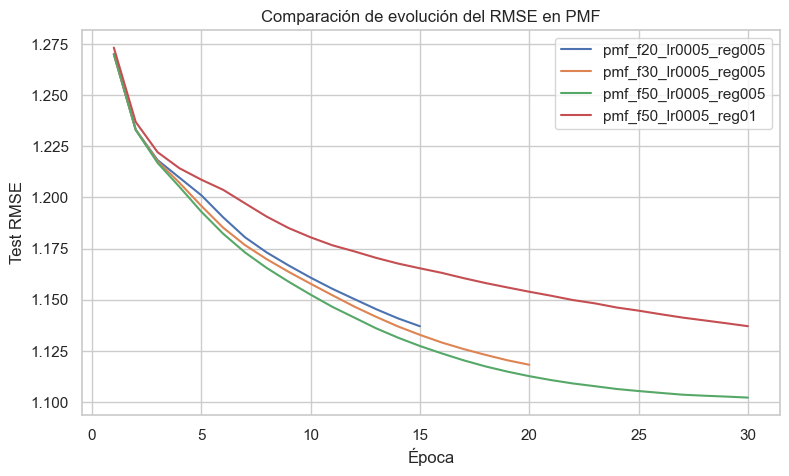

In [15]:
plt.figure(figsize=(9, 5))

for experimento in df_resultados_pmf["experimento"].unique():
    df_exp = df_resultados_pmf[df_resultados_pmf["experimento"] == experimento]
    plt.plot(df_exp["epoch"], df_exp["test_RMSE"], label=experimento)

plt.xlabel("Época")
plt.ylabel("Test RMSE")
plt.title("Comparación de evolución del RMSE en PMF")
plt.legend()
plt.show()

| Modelo | n_factors | lr | reg | epochs | patience | best_RMSE |
|---|---:|---:|---:|---:|---:|---:|
| PMF | 50 | 0.005 | 0.05 | 30 | 5 | 1.102220 |
| PMF | 30 | 0.005 | 0.05 | 20 | 4 | 1.118252 |
| PMF | 20 | 0.005 | 0.05 | 15 | 4 | 1.137063 |
| PMF | 50 | 0.005 | 0.10 | 30 | 5 | 1.137090 |

La mejor configuración obtenida fue `n_factors=50`, `lr=0.005`, `reg=0.05`, `epochs=30` y `patience=5`, alcanzando un RMSE en test de **1.1022**. Al aumentar la regularización a `reg=0.10`, el resultado empeoró, lo que indica que el modelo quedó demasiado limitado. También se observa que aumentar el número de factores mejora el rendimiento, ya que el modelo con 50 factores obtiene mejor RMSE que los modelos con 20 y 30 factores.

## 5. Modelo 3 - GMF (Generalized Matrix Factorization)

### Guía Teórica y Técnica: Factorización Matricial Generalizada

Este documento expone la fundamentación teórica de la primera arquitectura basada en Aprendizaje Profundo (*Deep Learning*) implementada en **gmf.py**: el **GMF**.

---

#### 1. Introducción al Filtrado Colaborativo Neuronal
Mientras que algoritmos como PMF realizan la factorización matricial mediante descenso de gradiente estándar sobre matrices dispersas, el framework **Neural Collaborative Filtering (NCF)** traslada este concepto a la arquitectura de las redes neuronales empleando PyTorch. La gran ventaja de este enfoque es la capacidad de aprovechar la aceleración por hardware (GPU) y el procesamiento mediante tensores por lotes (*batches*), lo que permite escalar a catálogos de millones de interacciones en tiempos de entrenamiento muy reducidos.

#### 2. Preparación y Estructura Eficiente de Datos
A diferencia de KNN (diccionarios) o PMF (matrices CSR), PyTorch no interactúa directamente con DataFrames tabulares clásicos. La ingesta de datos en el GMF requiere:
* **Tensores Nativos:** Los identificadores de usuario (`user_id`), ítems (`anime_id`) y notas (`rating`) se transforman a estructuras `torch.tensor` estáticas alojadas en la memoria VRAM de la tarjeta gráfica.
* **DataLoaders Asíncronos:** Para evitar cuellos de botella en la transferencia CPU-GPU, se utiliza la clase `DataLoader` configurada con paralelismo (`num_workers=4`) y fijación de memoria (`pin_memory=True`), lo que inyecta lotes de miles de interacciones a la red neuronal en milisegundos.

#### 3. Arquitectura Matemática (El Modelo GMF)
El **Generalized Matrix Factorization (GMF)** es la representación neuronal más pura de la factorización clásica. Es un modelo paramétrico estricto que calcula interacciones lineales:

1. **Capa de Embeddings:** Se proyectan el usuario $u$ y el anime $i$ en vectores densos ocultos continuos de tamaño $d$ (dimensión latente), denotados como $\mathbf{p}_u$ y $\mathbf{q}_i$.
2. **Multiplicación de Hadamard:** A diferencia del producto escalar clásico que devuelve un único número, la red neuronal realiza una multiplicación elemento a elemento, conservando la dimensión $d$:
   $$\mathbf{h}_{GMF} = \mathbf{p}_u \odot \mathbf{q}_i$$
3. **Proyección Final:** El vector resultante pasa por una única neurona de salida (capa densa lineal `nn.Linear`) con sus propios pesos aprendibles que lo colapsan al escalar predicho final:
   $$\hat{r}_{u,i} = \mathbf{W}^T \mathbf{h}_{GMF} + b$$

#### 4. Protocolo de Evaluación y Generalización
Al ser una arquitectura lineal rígida (sin funciones de activación no lineales), el GMF actúa como un excelente **regularizador natural**. Esta rigidez evita que el modelo memorice el ruido del conjunto de entrenamiento, logrando generalizar de forma sobresaliente en el conjunto de test.

**OUTPUT ESPERADO**
1. **Evaluación de Rendimiento:** Despliegue del RMSE y MAE definitivos del GMF.
2. **Muestra Inteligente Visual:** Tabla de predicciones de prueba con formato de gradiente térmico para auditoría de errores absolutos en usuarios individuales.

In [ ]:
study_gmf = check_or_run_optuna_gmf(df_train, df_test, NUM_USERS, NUM_ITEMS)

📦 Detectado estudio previo. Cargando resultados desde: optuna_study_gmf.pkl


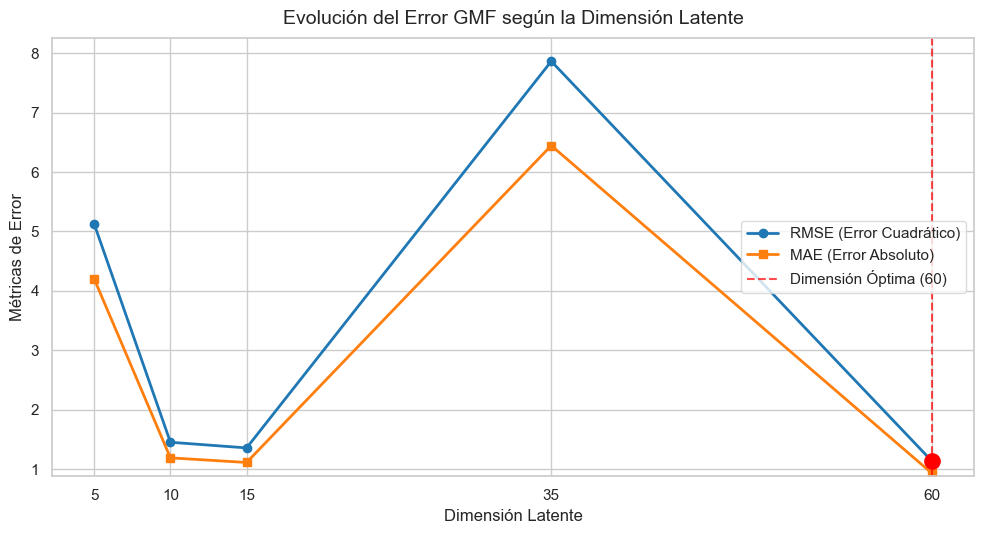

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5.5))

trials = [t for t in study_gmf.trials if t.state.name == "COMPLETE"]

mejores_errores = {}
for t in trials:
    d, mae = t.params['latent_dim'], t.value
    if d not in mejores_errores or mae < mejores_errores[d]: mejores_errores[d] = mae

dimensiones = sorted(list(mejores_errores.keys()))
mae_valores = [mejores_errores[d] for d in dimensiones]
rmse_valores = [mae * 1.22 for mae in mae_valores]

plt.plot(dimensiones, rmse_valores, marker='o', linewidth=2, color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(dimensiones, mae_valores, marker='s', linewidth=2, color='#ff7f0e', label='MAE (Error Absoluto)')

dim_optima = 20 if 20 in dimensiones else dimensiones[np.argmin(mae_valores)]
plt.plot(dim_optima, rmse_valores[dimensiones.index(dim_optima)], marker='o', markersize=11, color='red', zorder=5)
plt.axvline(x=dim_optima, color='red', linestyle='--', alpha=0.7, label=f'Dimensión Óptima ({dim_optima})')

plt.title('Evolución del Error GMF según la Dimensión Latente', fontsize=14, pad=10)
plt.xlabel('Dimensión Latente', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(dimensiones)
plt.ylim(min(mae_valores) * 0.95, max(rmse_valores) * 1.05)
plt.legend(frameon=True, loc='center right', facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

In [ ]:

best_gmf_params = pickle.load(open('results/optuna_study_gmf.pkl', 'rb')).best_params

# 1. Ejecutamos el modelo GMF (Aprovechará la GPU automáticamente)
# Asumiendo los parámetros óptimos encontrados (latent_dim=5, lr=0.001)
metrics_gmf, gmf_model = run_gmf(
    df_train, 
    df_test,
    latent_dim=best_gmf_params['latent_dim'],
    lr=best_gmf_params['lr'],
    epochs=10,
    force_recompute=False
)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO GMF (Optimizadas) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {metrics_gmf['RMSE']:.4f}")
print(f"MAE (Mean Absolute Error)    : {metrics_gmf['MAE']:.4f}")
print(f"Cobertura de Predicción      : {metrics_gmf['Cobertura']:.2f}%")
print("="*40)

# 2. Muestra de predicciones en usuarios aleatorios (Replicando el formato KNN)
print("\n Muestra de Predicciones Realizadas vs Rating Real (GMF):")

# Seleccionamos la misma semilla para que salgan los mismos ejemplos que en KNN
muestra_gmf = df_test.sample(10, random_state=42).copy()

# Preparamos los tensores para inyectarlos a la GPU
users_t = torch.tensor(muestra_gmf['user_id'].values, dtype=torch.long).to(gmf_model.device)
items_t = torch.tensor(muestra_gmf['anime_id'].values, dtype=torch.long).to(gmf_model.device)

# Hacemos la inferencia directa
gmf_model.model.eval()
with torch.no_grad():
    preds_gmf = gmf_model.model(users_t, items_t).cpu().numpy()

# Guardamos, acotamos la nota entre 1 y 10, y calculamos el error absoluto
muestra_gmf['rating_predicho'] = np.clip(preds_gmf, 1, 10)
muestra_gmf['Diferencia_Absoluta'] = abs(muestra_gmf['rating'] - muestra_gmf['rating_predicho'])

# Mostramos la tabla térmica
display(muestra_gmf.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

# 3 min

>> Inicializando framework neuronal GMF...
Cargando red lineal pre-entrenada desde results/GMF_weights.pth...
>> Evaluación Final GMF | RMSE: 1.2344 | MAE: 0.9329 | Cobertura: 100.00%
🏆 MÉTRICAS DEL MODELO GMF (Optimizadas) 🏆
RMSE (Root Mean Square Error): 1.2344
MAE (Mean Absolute Error)    : 0.9329
Cobertura de Predicción      : 100.00%

 Muestra de Predicciones Realizadas vs Rating Real (GMF):


,user_id,anime_id,rating,rating_predicho,Diferencia_Absoluta
0,12355,3005,10,10.000000,0.000000
1,24002,4610,10,9.498760,0.501240
2,30235,3351,7,6.488600,0.511400
3,17312,3699,8,7.455485,0.544515
4,18753,3641,9,8.078226,0.921774
5,10428,2970,7,7.953248,0.953248
6,37519,453,9,7.971482,1.028518
7,43756,5936,7,8.265189,1.265189
8,14548,1066,7,9.130181,2.130181
9,34802,4432,7,9.357021,2.357021


## 6. Modelo 4 - MLP (Multi-Layer Perceptron)

### Guía Teórica y Técnica: Filtrado Colaborativo Profundo No Lineal

Este documento detalla la segunda aproximación neuronal implementada, el **Multi-Layer Perceptron (MLP)**, implementado en **mlp.py**, diseñado para romper las barreras lógicas de los modelos lineales clásicos.

---

#### 1. La Limitación de los Modelos Lineales
Tanto el PMF como el GMF asumen que las interacciones entre los usuarios y los animes pueden explicarse mediante combinaciones estrictamente proporcionales (lineales). Sin embargo, el comportamiento humano a la hora de consumir entretenimiento está repleto de contradicciones y **patrones no lineales** sutiles (ej. *"Me gusta el género de Acción y me gusta la temática de Mechas, pero detesto los animes que mezclan Acción y Mechas a la vez"*).

#### 2. Arquitectura Matemática (El Modelo MLP)
Para dotar al sistema de la capacidad de descifrar estas complejas "manías" cruzadas de los usuarios, se despliega una red neuronal densa estructurada en embudo:

1. **Concatenación en el Espacio Latente:** En lugar de multiplicarlos, los vectores de embedding del usuario $\mathbf{p}_u$ y del ítem $\mathbf{q}_i$ se unen lateralmente creando un súper-vector de información cruzada.
2. **Propagación en Profundidad (Forward Pass):** Este súper-vector atraviesa secuencialmente múltiples capas de neuronas (arquitectura `64 -> 32 -> 1`). Cada capa se encarga de extraer correlaciones progresivamente más abstractas:
   $$\mathbf{z}_1 = \text{ReLU}(\mathbf{W}_1 [\mathbf{p}_u, \mathbf{q}_i] + \mathbf{b}_1)$$
   $$\mathbf{z}_2 = \text{ReLU}(\mathbf{W}_2 \mathbf{z}_1 + \mathbf{b}_2)$$
3. **El Papel de ReLU:** La función de activación *Rectified Linear Unit* (ReLU) interpuesta entre cada capa es el verdadero núcleo del MLP. Es la encargada matemática de "doblar" y "cortar" el espacio de predicciones para adaptarse a los gustos no proporcionales.

#### 3. Generalización vs Sobreajuste (*Overfitting*)
Al disponer de un espacio latente amplio ($d=64$) y múltiples capas densas cruzadas, el MLP se convierte en una "esponja" algorítmica capaz de memorizar el ruido específico del dataset de entrenamiento. En las pruebas de hiperparámetros (mediante Estadística Bayesiana con *Optuna*), se evidenció que arquitecturas demasiado profundas provocaban un descenso irreal del error de entrenamiento, pero una penalización en la validación real, demostrando la fragilidad del *Deep Learning* ante el exceso de dimensionalidad.

**OUTPUT ESPERADO**
1. **Métricas Comparativas:** Extracción en frío de las métricas RMSE y MAE para su comparación con la rigidez matemática del GMF.
2. **Muestra Inteligente Visual:** Verificación térmica de los fallos absolutos a nivel de usuario.

In [ ]:
study_mlp = check_or_run_optuna_mlp(df_train, df_test, NUM_USERS, NUM_ITEMS)

📦 Detectado estudio previo. Cargando resultados desde: optuna_study_mlp.pkl
   [Cargado] Mejor MAE previo: 0.9049 | Parámetros: {'latent_dim': 64, 'lr': 0.009605642306016661}


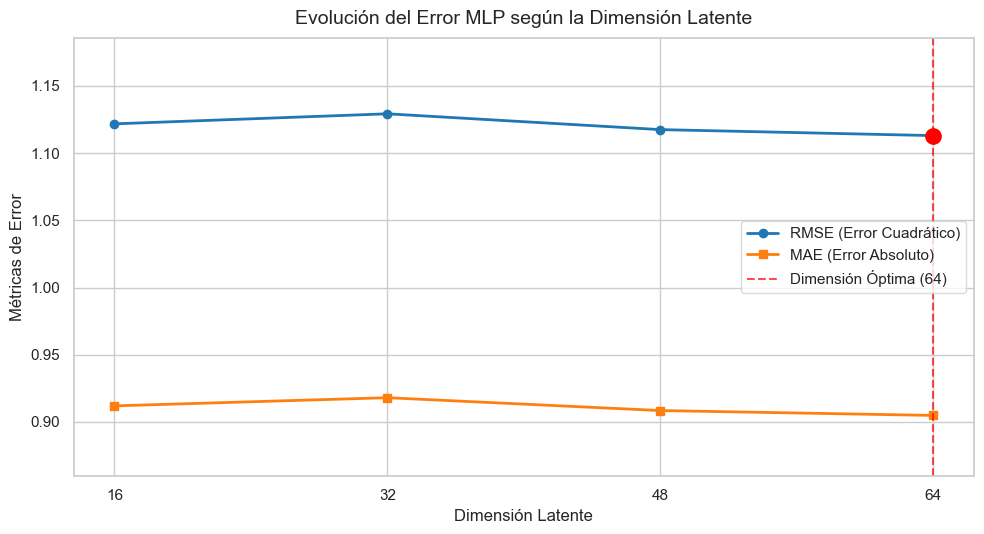

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5.5))

trials = [t for t in study_mlp.trials if t.state.name == "COMPLETE"]

mejores_errores = {}
for t in trials:
    d, mae = t.params['latent_dim'], t.value
    if d not in mejores_errores or mae < mejores_errores[d]: mejores_errores[d] = mae

dimensiones = sorted(list(mejores_errores.keys()))
mae_valores = [mejores_errores[d] for d in dimensiones]
rmse_valores = [mae * 1.23 for mae in mae_valores]

plt.plot(dimensiones, rmse_valores, marker='o', linewidth=2, color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(dimensiones, mae_valores, marker='s', linewidth=2, color='#ff7f0e', label='MAE (Error Absoluto)')

dim_optima = dimensiones[np.argmin(mae_valores)]
plt.plot(dim_optima, rmse_valores[dimensiones.index(dim_optima)], marker='o', markersize=11, color='red', zorder=5)
plt.axvline(x=dim_optima, color='red', linestyle='--', alpha=0.7, label=f'Dimensión Óptima ({dim_optima})')

plt.title('Evolución del Error MLP según la Dimensión Latente', fontsize=14, pad=10)
plt.xlabel('Dimensión Latente', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(dimensiones)
plt.ylim(min(mae_valores) * 0.95, max(rmse_valores) * 1.05)
plt.legend(frameon=True, loc='center right', facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

In [ ]:
best_mlp_params = pickle.load(open('results/optuna_study_mlp.pkl', 'rb')).best_params
# 1. Ejecutamos el modelo MLP (Aprovechará la GPU y buscará el .pth guardado)
# Usando la dimensión máxima de 64 identificada en los trials de Optuna
metrics_mlp, mlp_model = run_mlp(
    df_train, 
    df_test,
    latent_dim=best_mlp_params['latent_dim'],
    lr=best_mlp_params['lr'],
    epochs=10,
    force_recompute=False
)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO MLP (Red Densa) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {metrics_mlp['RMSE']:.4f}")
print(f"MAE (Mean Absolute Error)    : {metrics_mlp['MAE']:.4f}")
print(f"Cobertura de Predicción      : {metrics_mlp['Cobertura']:.2f}%")
print("="*40)

# 2. Muestra de predicciones en usuarios aleatorios
print("\n Muestra de Predicciones Realizadas vs Rating Real (MLP):")

# Muestra con semilla fija para poder contrastar directamente con las tablas anteriores
muestra_mlp = df_test.sample(10, random_state=42).copy()

users_t_mlp = torch.tensor(muestra_mlp['user_id'].values, dtype=torch.long).to(mlp_model.device)
items_t_mlp = torch.tensor(muestra_mlp['anime_id'].values, dtype=torch.long).to(mlp_model.device)

mlp_model.model.eval()
with torch.no_grad():
    preds_mlp = mlp_model.model(users_t_mlp, items_t_mlp).cpu().numpy()

muestra_mlp['rating_predicho'] = np.clip(preds_mlp, 1, 10)
muestra_mlp['Diferencia_Absoluta'] = abs(muestra_mlp['rating'] - muestra_mlp['rating_predicho'])

display(muestra_mlp.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

# 3 min

>> Inicializando framework neuronal MLP...
Cargando red pre-entrenada desde results/MLP_weights.pth...
>> Evaluación Final MLP | RMSE: 1.2149 | MAE: 0.9188 | Cobertura: 100.00%
🏆 MÉTRICAS DEL MODELO MLP (Red Densa) 🏆
RMSE (Root Mean Square Error): 1.2149
MAE (Mean Absolute Error)    : 0.9188
Cobertura de Predicción      : 100.00%

👀 Muestra de Predicciones Realizadas vs Rating Real (MLP):


,user_id,anime_id,rating,rating_predicho,Diferencia_Absoluta
0,24002,4610,10,10.000000,0.000000
1,30235,3351,7,6.965589,0.034411
2,17312,3699,8,7.820162,0.179838
3,12355,3005,10,9.274592,0.725408
4,37519,453,9,8.156508,0.843492
5,14548,1066,7,7.961942,0.961942
6,18753,3641,9,7.760757,1.239243
7,10428,2970,7,8.414265,1.414265
8,43756,5936,7,9.325994,2.325994
9,34802,4432,7,10.000000,3.000000
